# Notebook 07 — LSTM Model (Long Short-Term Memory)

**Goal**: Train a PyTorch LSTM to learn temporal patterns in stock features.

---

## Why LSTM for Finance?

Unlike tree-based models that see each row independently, LSTMs process **sequences**:

```
Tree model: f(features_today) → prediction
LSTM:       f(features_day1, features_day2, ..., features_day30) → prediction
```

This lets the LSTM learn **temporal patterns** like:
- Momentum build-up over weeks
- Volume surges before breakouts
- Mean-reversion after extreme moves

## LSTM Architecture

A standard LSTM cell has three gates:

1. **Forget gate**: $f_t = \sigma(W_f \cdot [h_{t-1}, x_t] + b_f)$
   - Decides what to forget from previous state

2. **Input gate**: $i_t = \sigma(W_i \cdot [h_{t-1}, x_t] + b_i)$
   - Decides what new information to store

3. **Output gate**: $o_t = \sigma(W_o \cdot [h_{t-1}, x_t] + b_o)$
   - Decides what to output

Cell state update: $C_t = f_t \odot C_{t-1} + i_t \odot \tanh(W_C \cdot [h_{t-1}, x_t] + b_C)$

Hidden state: $h_t = o_t \odot \tanh(C_t)$

## Our Configuration

| Parameter | Value | Rationale |
|-----------|-------|-----------|
| Sequence length | 30 days | ~6 weeks of trading |
| Hidden size | 128 | Balance complexity & speed |
| Layers | 2 | Stacked LSTM for deeper patterns |
| Dropout | 0.3 | Regularization |
| Learning rate | 0.001 | Adam optimizer |
| Batch size | 64 | GPU-friendly |
| Epochs | 100 | With early stopping (patience=10) |

In [1]:
import os, sys, gc, time
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import mean_squared_error, accuracy_score

from src.backtest import WalkForwardCV
from src.models import LSTMModel
from src.features import FeaturePipeline
from src.utils.constants import *

plt.style.use("seaborn-v0_8-whitegrid")

# Stabilize kernel after imports
gc.collect()
time.sleep(0.1)

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"✅ Setup complete | Device: {device}")

✅ Setup complete | Device: mps


## Step 1 — Load & Prepare Sequence Data

LSTM requires data in shape `(batch, sequence_length, features)`.
We slide a 30-day window across the feature matrix.

In [2]:
# Load processed data
processed_dir = DATA_DIR / "processed"
processed_files = sorted(processed_dir.glob("*.NS.parquet"))
processed_files = [f for f in processed_files if "prediction" not in f.stem]

all_data = {}
for f in processed_files:
    all_data[f.stem] = pd.read_parquet(f)

# Use ALL tickers to match XGBoost/LightGBM for ensemble alignment
sample_tickers = list(all_data.keys())

pipeline = FeaturePipeline()
target_horizon = 5

# Load clip_target from config (reduces sensitivity to outlier returns)
import yaml
with open(str(CONFIG_DIR / "model_params.yaml")) as _f:
    _model_cfg = yaml.safe_load(_f)
clip_target = _model_cfg.get("lstm", {}).get("clip_target", 0.03)
print(f"Target clipping: ±{clip_target:.0%}")

all_rows = []
for ticker in sample_tickers:
    df = all_data[ticker]
    feature_cols = pipeline.get_feature_columns(df)
    target = df["Close"].pct_change(target_horizon).shift(-target_horizon)
    # Clip extreme returns to reduce outlier sensitivity
    target = target.clip(-clip_target, clip_target)
    valid = target.dropna().index.intersection(df.dropna(subset=feature_cols).index)

    if len(valid) > 200:
        chunk = df.loc[valid, feature_cols].copy()
        chunk["_date"] = chunk.index
        chunk["_ticker"] = ticker
        chunk["_target"] = target.loc[valid].values
        all_rows.append(chunk)

# Replace inf/-inf with NaN, then fill remaining NaN with 0
panel = pd.concat(all_rows, ignore_index=True)
panel = panel.replace([np.inf, -np.inf], np.nan).fillna(0)
panel = panel.sort_values(["_ticker", "_date"]).reset_index(drop=True)

feature_cols = [c for c in panel.columns if c not in ("_date", "_ticker", "_target")]
X_all = panel[feature_cols]
y_all = panel["_target"]

print(f"Samples: {len(X_all):,}  Features: {len(feature_cols)}")
print(f"Tickers used: {panel['_ticker'].nunique()}")
print(f"Target range: [{y_all.min():.4f}, {y_all.max():.4f}] (clipped to ±{clip_target:.0%})")

Target clipping: ±3%
Samples: 246,508  Features: 206
Tickers used: 121
Target range: [-0.0300, 0.0300] (clipped to ±3%)


## Step 2 — Walk-Forward LSTM Training

Training LSTM is slower than tree models, so we use fewer tickers.
The walk-forward logic is identical — same embargo, same splits.

In [3]:
# Date-based walk-forward parameters (EXPANDING WINDOW)
train_days = 504
test_days = 63
embargo_days = 5
step_days = 63

model = LSTMModel(task="regression")

unique_dates = np.sort(panel["_date"].unique())
n_dates = len(unique_dates)

fold_results = []
fold_predictions = []
fold_num = 0

start = 0
while start + train_days + embargo_days + test_days <= n_dates:
    fold_num += 1

    train_end = start + train_days
    test_start = train_end + embargo_days
    test_end = min(test_start + test_days, n_dates)

    # EXPANDING WINDOW: always start training from date 0
    train_dates = unique_dates[0:train_end]
    test_dates = unique_dates[test_start:test_end]

    # Split validation from end of training period (~50 trading days)
    val_split = max(0, len(train_dates) - 50)
    val_date_set = set(train_dates[val_split:])

    train_fit_mask = panel["_date"].isin(train_dates) & ~panel["_date"].isin(val_date_set)
    val_mask = panel["_date"].isin(val_date_set)
    test_mask = panel["_date"].isin(test_dates)

    X_train = X_all.loc[train_fit_mask]
    y_train = y_all.loc[train_fit_mask]
    X_val = X_all.loc[val_mask]
    y_val = y_all.loc[val_mask]
    X_test = X_all.loc[test_mask]
    y_test = y_all.loc[test_mask]

    if len(X_train) < 200 or len(X_test) < 10:
        print(f"  Skipping fold {fold_num} (insufficient data)")
        start += step_days
        continue

    t0 = pd.Timestamp(train_dates[0]).strftime("%Y-%m-%d")
    t1 = pd.Timestamp(train_dates[-1]).strftime("%Y-%m-%d")
    t2 = pd.Timestamp(test_dates[0]).strftime("%Y-%m-%d")
    t3 = pd.Timestamp(test_dates[-1]).strftime("%Y-%m-%d")
    print(f"\n--- Fold {fold_num} | Train: {t0} → {t1} | Test: {t2} → {t3} ---")

    # Train LSTM with validation for early stopping
    model.fit(X_train, y_train, X_val=X_val, y_val=y_val)
    y_pred = model.predict(X_test)

    # LSTM returns fewer predictions due to seq_len window
    n_pred = len(y_pred)
    y_test_aligned = y_test.iloc[model.seq_len - 1:]
    if len(y_test_aligned) > n_pred:
        y_test_aligned = y_test_aligned.iloc[:n_pred]
    elif n_pred > len(y_test_aligned):
        y_pred = y_pred[:len(y_test_aligned)]

    rmse = np.sqrt(mean_squared_error(y_test_aligned, y_pred))
    direction_acc = accuracy_score(y_test_aligned > 0, y_pred > 0)

    fold_results.append({
        "fold": fold_num, "rmse": rmse, "direction_accuracy": direction_acc,
    })
    # Capture date and ticker for ensemble alignment
    test_idx = y_test_aligned.index
    fold_predictions.append(pd.DataFrame({
        "actual": y_test_aligned.values, "predicted": y_pred, "fold": fold_num,
        "Date": panel.loc[test_idx, "_date"].values,
        "Ticker": panel.loc[test_idx, "_ticker"].values,
    }, index=test_idx))

    print(f"  RMSE: {rmse:.4f}  Dir Acc: {direction_acc:.1%}  Predictions: {n_pred}")

    start += step_days

if fold_results:

    results_df = pd.DataFrame(fold_results)

    print(f"\n{'='*60}")

    print(f"AVERAGE: RMSE={results_df['rmse'].mean():.4f}  "          f"Dir Acc={results_df['direction_accuracy'].mean():.1%}")


--- Fold 1 | Train: 2017-03-03 → 2019-03-15 | Test: 2019-03-26 → 2019-06-28 ---
  RMSE: 0.0229  Dir Acc: 49.9%  Predictions: 6684

--- Fold 2 | Train: 2017-03-03 → 2019-06-21 | Test: 2019-07-01 → 2019-10-01 ---
  RMSE: 0.0244  Dir Acc: 42.5%  Predictions: 6769

--- Fold 3 | Train: 2017-03-03 → 2019-09-24 | Test: 2019-10-03 → 2020-01-03 ---
  RMSE: 0.0222  Dir Acc: 55.4%  Predictions: 6775

--- Fold 4 | Train: 2017-03-03 → 2019-12-27 | Test: 2020-01-06 → 2020-04-07 ---
  RMSE: 0.0260  Dir Acc: 41.0%  Predictions: 6775

--- Fold 5 | Train: 2017-03-03 → 2020-03-27 | Test: 2020-04-08 → 2020-07-09 ---
  RMSE: 0.0254  Dir Acc: 56.9%  Predictions: 6864

--- Fold 6 | Train: 2017-03-03 → 2020-07-02 | Test: 2020-07-10 → 2020-10-07 ---
  RMSE: 0.0242  Dir Acc: 53.6%  Predictions: 6955

--- Fold 7 | Train: 2017-03-03 → 2020-09-29 | Test: 2020-10-08 → 2021-01-06 ---
  RMSE: 0.0241  Dir Acc: 68.1%  Predictions: 6964

--- Fold 8 | Train: 2017-03-03 → 2020-12-30 | Test: 2021-01-07 → 2021-04-09 ---
  

## Step 3 — Training Loss Curve

Let's plot the training loss to check for overfitting.

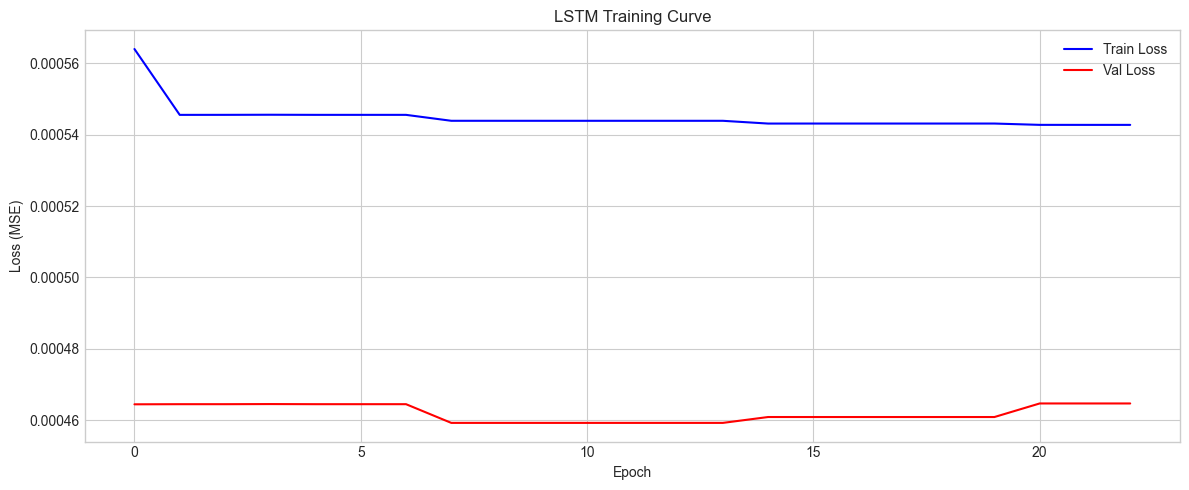

In [4]:
if hasattr(model, 'train_losses') and model.train_losses:
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(model.train_losses, label="Train Loss", color="blue")
    if hasattr(model, 'val_losses') and model.val_losses:
        ax.plot(model.val_losses, label="Val Loss", color="red")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("LSTM Training Curve")
    ax.legend()
    plt.tight_layout()
    plt.savefig(REPORTS_DIR / "lstm_training_curve.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Training curve not available")

## Step 4 — Save Model & Predictions

In [5]:
model.save(MODELS_DIR / "lstm_model.pt")
print(f"✅ LSTM model saved")

if fold_predictions:
    preds_df = pd.concat(fold_predictions).reset_index(drop=True)
    preds_df.to_parquet(DATA_DIR / "processed" / "lstm_predictions.parquet")

    print(f"✅ Predictions saved: {len(preds_df):,} rows, {preds_df['Ticker'].nunique()} tickers")
    print(f"   Columns: {list(preds_df.columns)}")

✅ LSTM model saved
✅ Predictions saved: 187,703 rows, 121 tickers
   Columns: ['actual', 'predicted', 'fold', 'Date', 'Ticker']


## ✅ LSTM Training Complete!

**Key observations:**
- LSTM requires more data and longer training than tree models
- Sequence length of 30 days captures medium-term patterns
- Direction accuracy shows whether temporal patterns add value
- The ensemble (Notebook 09) will combine LSTM with tree models

**Next:** Proceed to **Notebook 08 — Transformer Model**

---
*Educational project. Not financial advice.*